In [1]:
import numpy as np
import pandas
from IMPtorch.restraints.release import stereochemistry
from IMPtorch.samplers.mcmc import MCMC
from IMPtorch.representations import SystemRepresentation
import torch


print("hello world")

hello world


In [2]:
NUM_PARTICLES = 8
particles = SystemRepresentation(
    xyz_ref = torch.FloatTensor(NUM_PARTICLES,3).uniform_(0.1, 100.),
    rigid_body = torch.arange(NUM_PARTICLES),
    super_rigid_body = torch.arange(NUM_PARTICLES)
)

In [8]:
print(particles)

SystemRepresentation(xyz_ref=tensor([[43.4740, 87.1390, 20.9038],
        [20.6384, 59.0304, 49.8645],
        [50.3124, 26.7840, 61.0841],
        [20.6157, 32.3857, 20.6015],
        [48.6216, 28.9975, 10.3697],
        [43.1561, 65.1169, 37.9060],
        [41.2235, 53.6635, 72.6619],
        [25.4604, 64.4778, 99.0505]]), xyz_delta=tensor([]), delta_idx=tensor([]), delta_state_idx=tensor([]), state_idx=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), resolutions=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), mass=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), radius=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), volume=tensor([1., 1., 1., 1., 1., 1., 1., 1.]), atom_type=tensor([1, 1, 1, 1, 1, 1, 1, 1], dtype=torch.int32), res_num=tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.int32), ins_code=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), res_name=tensor([7, 7, 7, 7, 7, 7, 7, 7], dtype=torch.int32), fragment_id=tensor([0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32), fragment_start=

coordinates:  [[ 8.00000000e+01  0.00000000e+00  0.00000000e+00]
 [ 5.65685425e+01  5.65685425e+01  0.00000000e+00]
 [-3.49691118e-06  8.00000000e+01  0.00000000e+00]
 [-5.65685425e+01  5.65685425e+01  0.00000000e+00]
 [-8.00000000e+01 -6.99382235e-06  0.00000000e+00]
 [-5.65685310e+01 -5.65685501e+01  0.00000000e+00]
 [ 9.53990480e-07 -8.00000000e+01  0.00000000e+00]
 [ 5.65685616e+01 -5.65685234e+01  0.00000000e+00]
 [ 8.00000000e+01  0.00000000e+00 -3.65000000e+01]
 [ 5.65685425e+01  5.65685425e+01 -3.65000000e+01]
 [-3.49691118e-06  8.00000000e+01 -3.65000000e+01]
 [-5.65685425e+01  5.65685425e+01 -3.65000000e+01]
 [-8.00000000e+01 -6.99382235e-06 -3.65000000e+01]
 [-5.65685310e+01 -5.65685501e+01 -3.65000000e+01]
 [ 9.53990480e-07 -8.00000000e+01 -3.65000000e+01]
 [ 5.65685616e+01 -5.65685234e+01 -3.65000000e+01]
 [ 5.85946960e+01  1.82225971e+01 -5.65000000e+01]
 [ 2.85473862e+01  5.43180313e+01 -5.65000000e+01]
 [-1.82226009e+01  5.85946960e+01 -5.65000000e+01]
 [-5.43180313e+01

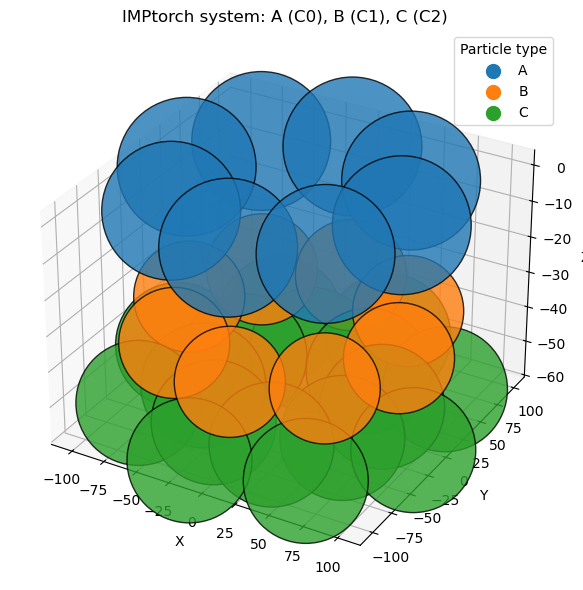

array_A = np.array([
    [80, 0, 0],
    [56.57, 56.57, 0],
    [-0.00, 80, 0],
    [-56.57, 56.57, 0],
    [-80, -0.00, 0],
    [-56.57, -56.57, 0],
    [0.00, -80, 0],
    [56.57, -56.57, 0],
])

array_B = np.array([
    [80, 0, -36.50],
    [56.57, 56.57, -36.50],
    [-0.00, 80, -36.50],
    [-56.57, 56.57, -36.50],
    [-80, -0.00, -36.50],
    [-56.57, -56.57, -36.50],
    [0.00, -80, -36.50],
    [56.57, -56.57, -36.50],
])

array_C = np.array([
    [58.59, 18.22, -56.50],  # pair 1
    [28.55, 54.32, -56.50],
    [-18.22, 58.59, -56.50],  # pair 2
    [-54.32, 28.55, -56.50],
    [-58.59, -18.22, -56.50],  # pair 3
    [-28.55, -54.32, -56.50],
    [18.22, -58.59, -56.50],  # pair 4
    [54.32, -28.55, -56.50],
    [101.41, -18.22, -56.50],  # pair 5
    [84.59, 58.82, -56.50],
    [18.22, 101.41, -56.50],  # pair 6
    [-58.82, 84.59, -56.50],
    [-101.41, 18.22, -56.50],  # pair 7
    [-84.59, -58.82, -56.50],
    [-18.22, -101.41, -56.50],  # pair 8
    [58.82, -84.59, -56.

In [3]:
import torch
import math
from dataclasses import dataclass
from typing import Dict
from IMPtorch.representations import SystemRepresentation

@dataclass
class SystemParameters:
    box_size: float = 400.0
    radii: Dict[str, float] = None
    tol: float = 0.5
    N_tetramers: int = 8
    vertical_drop: float = 20.0

    def __post_init__(self):
        # default radii and counts
        if self.radii is None:
            self.radii = {'A': 20.0, 'B': 16.0, 'C': 18.0}
        # derive distances
        self.AB = self.radii['A'] + self.radii['B'] + self.tol
        self.BC = self.radii['B'] + self.radii['C'] + self.tol
        # radius of circle on which A/B sit
        self.RA = 80.0

    def build_system(self) -> SystemRepresentation:
        N        = self.N_tetramers
        # 1) generate θ angles
        #theta    = torch.linspace(0, 2*math.pi, N, endpoint=False)
        theta = 2*math.pi * torch.arange(N, dtype=torch.float32) / N
        # 2) A coords: (N,3)
        A_xy     = self.RA * torch.stack([theta.cos(), theta.sin()], dim=1)
        A_xyz    = torch.cat([A_xy, torch.zeros(N,1)], dim=1)
        # 3) B directly below A
        B_xyz    = A_xyz.clone()
        B_xyz[:,2] -= self.AB
        # 4) compute horizontal δ for C placement
        #delta    = torch.sqrt(self.BC**2 - self.vertical_drop**2)
        # 4) compute horizontal δ for C placement as a Python float
        delta    = math.sqrt(self.BC**2 - self.vertical_drop**2)
        # 5) find best φ in torch (coarse search)
        phis     = torch.linspace(0, math.pi/2, 50)
        best_phi = None
        best_min = -1.0
        desired  = 2*self.radii['C'] + self.tol

        # helper to build C positions given φ
        def make_C(phi):
            # v vectors in plane
            v = delta * torch.stack([-theta.sin(), theta.cos()], dim=1)  # (N,2)
            # rotate v by φ
            R = torch.tensor([[phi.cos(), -phi.sin()],
                              [phi.sin(),  phi.cos()]])
            v2 = v @ R.T                                    # (N,2)
            zc = -self.AB - self.vertical_drop
            C1 = torch.cat([A_xy + v2, torch.full((N,1), zc)], dim=1)
            C2 = torch.cat([A_xy - v2, torch.full((N,1), zc)], dim=1)
            return torch.cat([C1, C2], dim=0)               # (2N,3)

        # search φ
        for φ in phis:
            C   = make_C(φ)
            # compute all pairwise C–C dists between different tetramers
            C1, C2 = C.unsqueeze(1), C.unsqueeze(0)           # broadcast (2N,2N,3)
            D     = torch.norm(C1 - C2, dim=2)                # (2N,2N)
            # mask self and intra‐tetramer pairs
            mask  = torch.eye(2*N, dtype=bool)
            D.masked_fill_(mask, float('inf'))
            m     = D.min().item()
            if m >= desired and m > best_min:
                best_min, best_phi = m, φ

        if best_phi is None:
            raise RuntimeError("no non‑overlapping φ found")

        C_xyz = make_C(best_phi)

        # 6) concatenate all particles: A, B, C
        xyz_ref = torch.cat([A_xyz, B_xyz, C_xyz], dim=0)    # (N_tot,3)
        N_tot   = xyz_ref.shape[0]

        # 7) define rigid_body: group each tetramer as one rigid body
        #    so particles [0..N-1]=A, [N..2N-1]=B, [2N..4N-1]=C
        #    we assign: rigid_body[i] = ⌊i/N⌋
        tet_idx = torch.arange(N_tot) // N

        # 8) super_rigid_body: e.g. group by type A vs B vs C
        type_ids = (
            torch.zeros(N, dtype=torch.long)                      # A’s = 0
            .tolist() +
            torch.ones(N, dtype=torch.long).tolist()               # B’s = 1
        )
        type_ids += (2*torch.ones(2*N, dtype=torch.long)).tolist()  # C’s = 2
        super_rb = torch.tensor(type_ids, dtype=torch.long)

        # 9) build SystemRepresentation
        system = SystemRepresentation(
            xyz_ref         = xyz_ref,
            rigid_body      = tet_idx,
            super_rigid_body= super_rb
        )

        # 10) attach per‑particle radii as a property (if supported)
        # You might have an API like system.register_property(...)
        try:
            system.register_property('radius',
                                     torch.tensor(
                                       [self.radii['A']]*N +
                                       [self.radii['B']]*N +
                                       [self.radii['C']]*2*N
                                     ))
        except AttributeError:
            # or just set as an attribute
            system.radius = torch.tensor(
                [self.radii['A']]*N +
                [self.radii['B']]*N +
                [self.radii['C']]*2*N
            )

        return system

# usage:
params = SystemParameters()
particles = params.build_system()

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

# extract data from your SystemRepresentation
xyz = particles.xyz_ref.detach().cpu().numpy()         # (N_tot,3)
print("coordinates: ", xyz)
types = particles.super_rigid_body.cpu().numpy()       # 0=A, 1=B, 2=C
radii = particles.radius.cpu().numpy()                 # per‑particle radius

# define a color for each type
color_map = {0: "C0", 1: "C1", 2: "C2"}   # you can pick any matplotlib colors
colors = [color_map[t] for t in types]

# optionally scale marker size by radius (you may need to tune the scale factor)
size = (radii * 5)**2    # e.g. radius*5 and then squared for “area” 

# make the plot
fig = plt.figure(figsize=(6,6))
ax  = fig.add_subplot(111, projection="3d")
sc = ax.scatter(
    xyz[:,0], xyz[:,1], xyz[:,2],
    c=colors,
    s=size,
    alpha=0.8,
    edgecolor="k"
)

# make a legend
for t, label in enumerate(["A","B","C"]):
    ax.scatter([], [], [], c=color_map[t], label=label, s=100)
ax.legend(title="Particle type")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("IMPtorch system: A (C0), B (C1), C (C2)")
plt.tight_layout()
plt.show()

# Extract coordinates by particle type
N = 8  # Number of tetramers
array_A = xyz[:N]  # First N particles are type A
array_B = xyz[N:2*N]  # Next N particles are type B
array_C = xyz[2*N:]  # Remaining 2*N particles are type C

# Helper function to format numbers without decimal points when they're integers
def format_num(x):
    if abs(x - round(x)) < 1e-10:
        return f"{int(round(x))}"
    else:
        return f"{x:.2f}"

# Print coordinates in the desired format
print("array_A = np.array([")
for coord in array_A:
    print(f"    [{format_num(coord[0])}, {format_num(coord[1])}, {format_num(coord[2])}],")
print("])\n")

print("array_B = np.array([")
for coord in array_B:
    print(f"    [{format_num(coord[0])}, {format_num(coord[1])}, {format_num(coord[2])}],")
print("])\n")

print("array_C = np.array([")
for i in range(0, len(array_C), 2):
    print(f"    [{format_num(array_C[i][0])}, {format_num(array_C[i][1])}, {format_num(array_C[i][2])}],  # pair {i//2 + 1}")
    if i + 1 < len(array_C):
        print(f"    [{format_num(array_C[i+1][0])}, {format_num(array_C[i+1][1])}, {format_num(array_C[i+1][2])}],")
print("])")

# Create and print the dictionary
particle_dict = {'A': array_A, 'B': array_B, 'C': array_C}
#print("\nreturn {'A': array_A, 'B': array_B, 'C': array_C}")


In [ ]:
# At this point, write a restraint function in IMPtorch, the class is going to contain pairwise restraint functions 

from IMPtorch.restraints import Restraint 

class pair_distance_score(Restraint):
    """A repulsive score based on 0.5*k*(x-x_0)^2 using IMPtorch restraint base class"""
    
    